# Chapter 11.5: Fairness in Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Distinguish consumer fairness from provider fairness** in recommendation systems
2. **Measure group fairness** using demographic parity and equal opportunity metrics
3. **Assess individual fairness** — similar users should receive similar recommendations
4. **Understand two-sided marketplace fairness** balancing buyer and seller interests
5. **Implement fairness-constrained optimisation** by adding fairness terms to the ranking objective
6. **Quantify the accuracy-fairness trade-off** and visualise Pareto frontiers
7. **Build a fairness-constrained re-ranking algorithm** for provider exposure fairness

## Prerequisites

- Chapters 11.1-11.4
- Basic linear programming / optimisation concepts
- Understanding of recommendation ranking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.5_fairness.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.5_fairness.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Types of Fairness in Recommendation

| Dimension | Definition | Example |
|-----------|------------|---------|
| **Consumer (C-fairness)** | Equal recommendation quality across user groups | Male and female users get equally good movie recommendations |
| **Provider (P-fairness)** | Equal exposure/opportunity for item providers | Small sellers get fair visibility on a marketplace |
| **Two-sided** | Balance both consumer and provider interests | Uber matches riders to drivers fairly for both sides |

Reference: Burke et al., "Balanced Neighborhoods for Multi-Sided Fairness in Recommendation" (FAT* 2018).

> **💡 Concept:** Fairness in recommendation is fundamentally different from fairness in classification. In classification, we predict a label. In recommendation, we allocate a scarce resource: user attention.

In [2]:
# Generate synthetic data with user groups and item providers
rng = np.random.RandomState(42)
NUM_USERS = 400
NUM_ITEMS = 200
K = 10  # recommendation list size

# User demographics (protected attribute)
user_group = rng.choice(['A', 'B'], size=NUM_USERS, p=[0.6, 0.4])

# Item providers (two groups: large and small sellers)
item_provider = rng.choice(['large', 'small'], size=NUM_ITEMS, p=[0.3, 0.7])

# True relevance: users have preferences, but group B has sparser data
# (simulating historical data imbalance)
user_factors = rng.randn(NUM_USERS, 10)
item_factors = rng.randn(NUM_ITEMS, 10)

# Group B has noisier factor estimates (less data)
for u in range(NUM_USERS):
    if user_group[u] == 'B':
        user_factors[u] += rng.randn(10) * 0.5  # more noise

# True relevance scores
true_scores = user_factors @ item_factors.T
# Normalise to [0, 1]
true_scores = (true_scores - true_scores.min()) / (true_scores.max() - true_scores.min())

# Ground truth: top relevant items per user
ground_truth = {}
for u in range(NUM_USERS):
    top_items = np.argsort(-true_scores[u])[:20]
    ground_truth[u] = set(top_items)

# Baseline model: noisy estimate of true scores (biased against group B)
model_scores = true_scores + rng.randn(NUM_USERS, NUM_ITEMS) * 0.1
# Add extra noise for group B (simulating worse model quality)
for u in range(NUM_USERS):
    if user_group[u] == 'B':
        model_scores[u] += rng.randn(NUM_ITEMS) * 0.2

# Generate recommendations
recommendations = {}
for u in range(NUM_USERS):
    top_k = np.argsort(-model_scores[u])[:K]
    recommendations[u] = list(top_k)

print(f"Users: {NUM_USERS} (Group A: {sum(user_group=='A')}, Group B: {sum(user_group=='B')})")
print(f"Items: {NUM_ITEMS} (Large providers: {sum(item_provider=='large')}, Small: {sum(item_provider=='small')})")

Users: 400 (Group A: 235, Group B: 165)
Items: 200 (Large providers: 56, Small: 144)


## 2. Consumer Fairness: Group Fairness Metrics

### Demographic Parity
The recommendation quality should be equal across user groups:

$$\text{DP Gap} = |\text{Metric}(\text{Group A}) - \text{Metric}(\text{Group B})|$$

### Equal Opportunity
The probability of a relevant item being recommended should be equal across groups:

$$\text{EO Gap} = |P(\text{rec} | \text{relevant}, \text{Group A}) - P(\text{rec} | \text{relevant}, \text{Group B})|$$

=== Consumer Fairness: Group Metrics ===
NDCG@10:  Group A = 0.5736, Group B = 0.3227, Gap = 0.2509
HitRate@10:  Group A = 1.0000, Group B = 0.9697, Gap = 0.0303


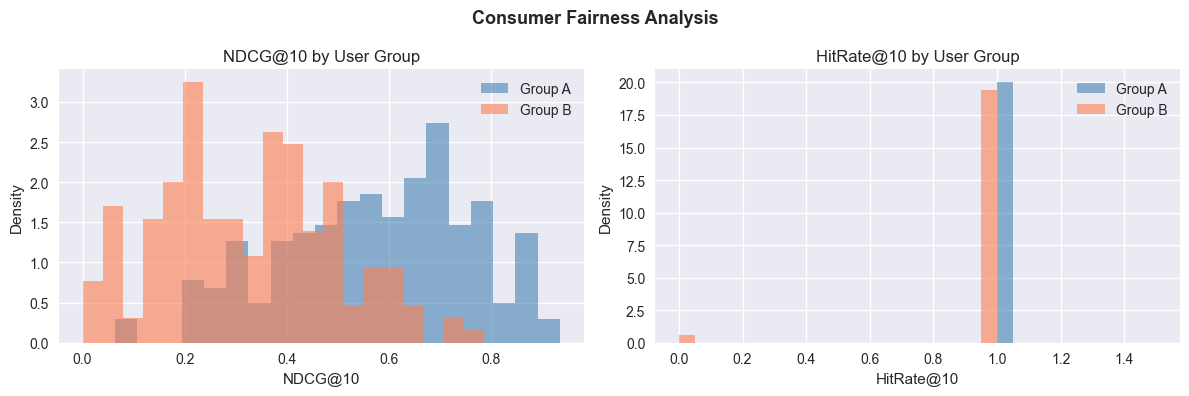

In [3]:
def ndcg_at_k(rec_list, relevant_set, k):
    """Compute NDCG@K for a single user."""
    relevances = [1.0 if item in relevant_set else 0.0 for item in rec_list[:k]]
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(relevances))
    n_rel = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_rel))
    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(rec_list, relevant_set, k):
    return 1.0 if len(set(rec_list[:k]) & relevant_set) > 0 else 0.0


# Compute per-group metrics
group_metrics = defaultdict(lambda: defaultdict(list))

for u in range(NUM_USERS):
    grp = user_group[u]
    ndcg = ndcg_at_k(recommendations[u], ground_truth[u], K)
    hr = hit_rate_at_k(recommendations[u], ground_truth[u], K)
    group_metrics[grp]['NDCG'].append(ndcg)
    group_metrics[grp]['HitRate'].append(hr)

print("=== Consumer Fairness: Group Metrics ===")
for metric in ['NDCG', 'HitRate']:
    mean_a = np.mean(group_metrics['A'][metric])
    mean_b = np.mean(group_metrics['B'][metric])
    gap = abs(mean_a - mean_b)
    print(f"{metric}@{K}:  Group A = {mean_a:.4f}, Group B = {mean_b:.4f}, Gap = {gap:.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, metric in enumerate(['NDCG', 'HitRate']):
    ax = axes[idx]
    ax.hist(group_metrics['A'][metric], bins=20, alpha=0.6, label='Group A', color='steelblue', density=True)
    ax.hist(group_metrics['B'][metric], bins=20, alpha=0.6, label='Group B', color='coral', density=True)
    ax.set_xlabel(f'{metric}@{K}')
    ax.set_ylabel('Density')
    ax.set_title(f'{metric}@{K} by User Group')
    ax.legend()

plt.suptitle('Consumer Fairness Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Provider Fairness: Exposure Equality

Provider fairness ensures that items from different providers receive proportional exposure.

$$\text{Exposure}(g) = \sum_{u} \sum_{i \in g} \mathbb{1}[i \in \text{Rec}_u]$$

We can measure the exposure ratio and compare it to a fair target (e.g., proportional to provider size or item quality).

Reference: Singh & Joachims, "Fairness of Exposure in Rankings" (KDD 2018).

=== Provider Fairness ===
Large providers: 56 items (28.0% of catalog), 28.3% of exposure
Small providers: 144 items (72.0% of catalog), 71.7% of exposure

Exposure disparity: Large gets 1.01x their fair share


/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78211/1835945890.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([large_item_exposures, small_item_exposures], labels=['Large Providers', 'Small Providers'])


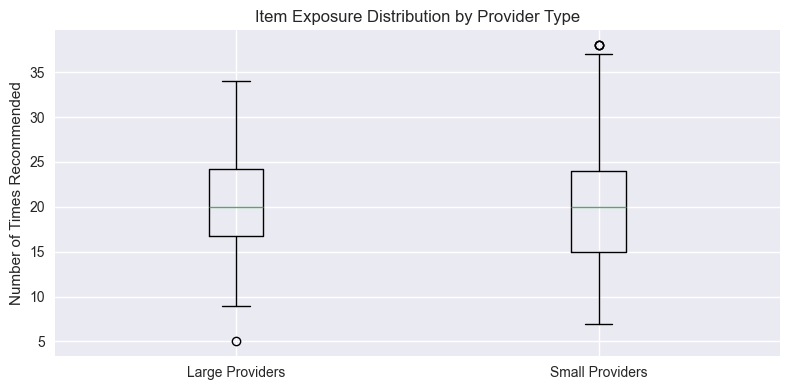

In [4]:
# Compute provider exposure
provider_exposure = Counter()
for u in range(NUM_USERS):
    for item in recommendations[u]:
        provider_exposure[item_provider[item]] += 1

total_exposure = sum(provider_exposure.values())
n_large = sum(item_provider == 'large')
n_small = sum(item_provider == 'small')

exposure_large = provider_exposure['large'] / total_exposure
exposure_small = provider_exposure['small'] / total_exposure
fair_share_large = n_large / NUM_ITEMS  # proportional to catalog size
fair_share_small = n_small / NUM_ITEMS

print("=== Provider Fairness ===")
print(f"Large providers: {n_large} items ({fair_share_large:.1%} of catalog), "
      f"{exposure_large:.1%} of exposure")
print(f"Small providers: {n_small} items ({fair_share_small:.1%} of catalog), "
      f"{exposure_small:.1%} of exposure")
print(f"\nExposure disparity: Large gets {exposure_large/fair_share_large:.2f}x their fair share")

# Per-item exposure
item_exposure = Counter()
for u in range(NUM_USERS):
    for item in recommendations[u]:
        item_exposure[item] += 1

large_item_exposures = [item_exposure.get(i, 0) for i in range(NUM_ITEMS) if item_provider[i] == 'large']
small_item_exposures = [item_exposure.get(i, 0) for i in range(NUM_ITEMS) if item_provider[i] == 'small']

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([large_item_exposures, small_item_exposures], labels=['Large Providers', 'Small Providers'])
ax.set_ylabel('Number of Times Recommended')
ax.set_title('Item Exposure Distribution by Provider Type')
plt.tight_layout()
plt.show()

## 4. Individual Fairness

Individual fairness requires that similar users receive similar recommendations:

$$d_{\text{rec}}(\text{Rec}_u, \text{Rec}_v) \leq L \cdot d_{\text{user}}(u, v)$$

where $d_{\text{rec}}$ measures recommendation list distance and $d_{\text{user}}$ measures user similarity.

> **💡 Concept:** Individual fairness is stricter than group fairness. Two users from different demographic groups but with identical preferences should get identical recommendations.

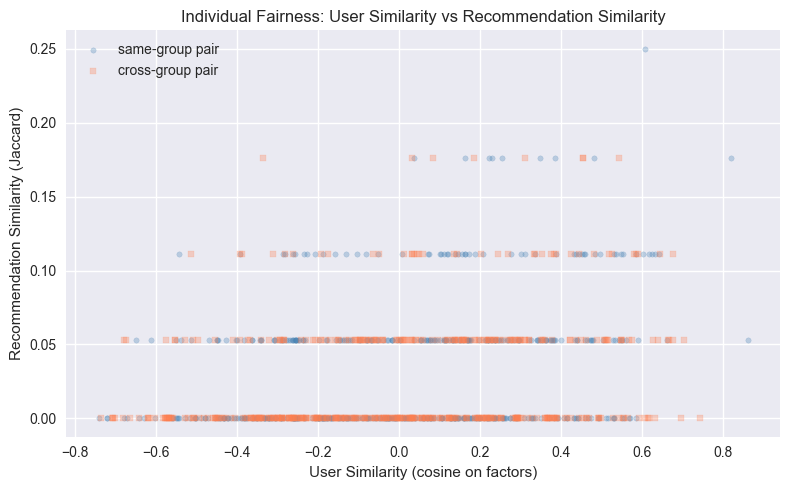

High-sim same-group pairs: avg rec similarity = 0.0497
High-sim cross-group pairs: avg rec similarity = 0.0403


In [5]:
# Measure individual fairness
def jaccard_similarity(list1, list2):
    set1, set2 = set(list1), set(list2)
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0

def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norm = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    return dot / norm if norm > 0 else 0.0

# Sample pairs of users and measure consistency
n_pairs = 1000
user_sims = []
rec_sims = []
pair_groups = []  # 'same' or 'cross'

for _ in range(n_pairs):
    u1, u2 = rng.choice(NUM_USERS, size=2, replace=False)
    user_sim = cosine_similarity(user_factors[u1], user_factors[u2])
    rec_sim = jaccard_similarity(recommendations[u1], recommendations[u2])
    user_sims.append(user_sim)
    rec_sims.append(rec_sim)
    pair_groups.append('same' if user_group[u1] == user_group[u2] else 'cross')

user_sims = np.array(user_sims)
rec_sims = np.array(rec_sims)

fig, ax = plt.subplots(figsize=(8, 5))
for pg, color, marker in [('same', 'steelblue', 'o'), ('cross', 'coral', 's')]:
    mask = np.array(pair_groups) == pg
    ax.scatter(user_sims[mask], rec_sims[mask], alpha=0.3, s=15, color=color, marker=marker, label=f'{pg}-group pair')
ax.set_xlabel('User Similarity (cosine on factors)')
ax.set_ylabel('Recommendation Similarity (Jaccard)')
ax.set_title('Individual Fairness: User Similarity vs Recommendation Similarity')
ax.legend()
plt.tight_layout()
plt.show()

# Check if cross-group similar users get less similar recommendations
high_sim = user_sims > np.percentile(user_sims, 75)
for pg in ['same', 'cross']:
    mask = (np.array(pair_groups) == pg) & high_sim
    print(f"High-sim {pg}-group pairs: avg rec similarity = {rec_sims[mask].mean():.4f}")

## 5. Fairness-Constrained Re-Ranking

Given a ranked list from the base model, we can re-rank to satisfy fairness constraints while minimising the loss in relevance.

**Greedy fairness-aware re-ranking** (adapted from Zehlike et al., "FA*IR: A Fair Top-k Ranking Algorithm", CIKM 2017):

At each position, select the item that maximises:

$$\text{score}(i) = (1 - \lambda) \cdot \text{relevance}(i) + \lambda \cdot \text{fairness\_bonus}(i)$$

where the fairness bonus gives priority to under-exposed providers.

In [6]:
def fairness_rerank(model_scores, item_provider, k, lambda_fair=0.5, target_ratio=None):
    """Greedy fairness-constrained re-ranking.
    
    Args:
        model_scores: array of shape (num_items,) with relevance scores
        item_provider: array of provider labels for each item
        k: list size
        lambda_fair: trade-off parameter (0 = pure relevance, 1 = pure fairness)
        target_ratio: target exposure ratio for 'small' providers (default: proportional)
    """
    providers = np.unique(item_provider)
    if target_ratio is None:
        # Proportional to catalog size
        target_ratio = {'small': np.mean(item_provider == 'small'),
                        'large': np.mean(item_provider == 'large')}
    
    # Normalise relevance scores to [0, 1]
    norm_scores = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
    
    selected = []
    selected_set = set()
    provider_counts = Counter()
    
    for pos in range(k):
        best_item = -1
        best_score = -np.inf
        
        for item in range(len(model_scores)):
            if item in selected_set:
                continue
            
            # Relevance component
            rel = norm_scores[item]
            
            # Fairness bonus: boost under-represented providers
            prov = item_provider[item]
            current_ratio = provider_counts.get(prov, 0) / max(pos, 1)
            deficit = target_ratio[prov] - current_ratio
            fairness_bonus = max(deficit, 0)
            
            combined = (1 - lambda_fair) * rel + lambda_fair * fairness_bonus
            
            if combined > best_score:
                best_score = combined
                best_item = item
        
        selected.append(best_item)
        selected_set.add(best_item)
        provider_counts[item_provider[best_item]] += 1
    
    return selected

# Apply fairness re-ranking for different lambda values
lambdas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
results = []

for lam in lambdas:
    fair_recs = {}
    for u in range(NUM_USERS):
        fair_recs[u] = fairness_rerank(model_scores[u], item_provider, K, lambda_fair=lam)
    
    # Compute NDCG and provider exposure
    ndcg_vals = [ndcg_at_k(fair_recs[u], ground_truth[u], K) for u in range(NUM_USERS)]
    prov_exp = Counter()
    for u in range(NUM_USERS):
        for item in fair_recs[u]:
            prov_exp[item_provider[item]] += 1
    total = sum(prov_exp.values())
    small_exposure = prov_exp['small'] / total
    
    results.append({
        'lambda': lam,
        'NDCG@10': np.mean(ndcg_vals),
        'Small Provider Exposure': small_exposure,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 lambda  NDCG@10  Small Provider Exposure
    0.0 0.470118                  0.71700
    0.2 0.468586                  0.71050
    0.4 0.467293                  0.70600
    0.6 0.465041                  0.70025
    0.8 0.465008                  0.70000
    1.0 0.082406                  0.70000


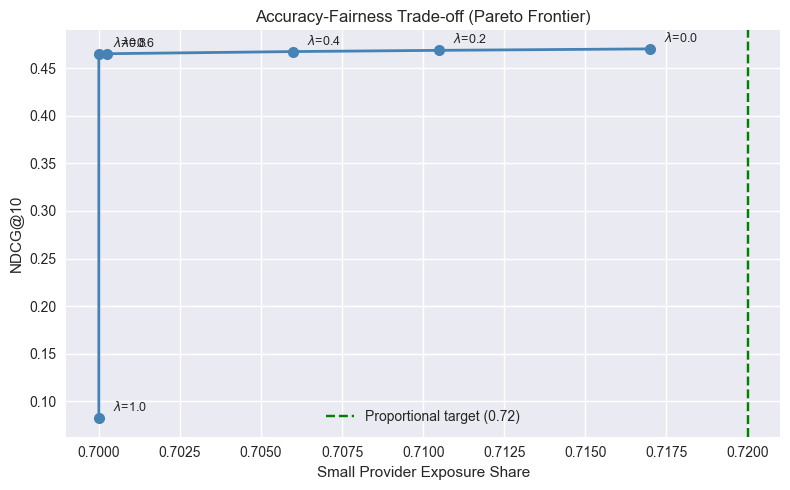

In [7]:
# Pareto frontier: Accuracy vs Fairness
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df['Small Provider Exposure'], results_df['NDCG@10'], 'o-', 
        color='steelblue', linewidth=2, markersize=8)

# Target fairness line
target_small = sum(item_provider == 'small') / NUM_ITEMS
ax.axvline(x=target_small, color='green', linestyle='--', label=f'Proportional target ({target_small:.2f})')

for _, row in results_df.iterrows():
    ax.annotate(f"$\\lambda$={row['lambda']:.1f}",
                (row['Small Provider Exposure'], row['NDCG@10']),
                textcoords='offset points', xytext=(10, 5), fontsize=9)

ax.set_xlabel('Small Provider Exposure Share')
ax.set_ylabel('NDCG@10')
ax.set_title('Accuracy-Fairness Trade-off (Pareto Frontier)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Two-Sided Marketplace Fairness

In a marketplace, we need to balance:
- **Buyer utility**: buyers get relevant recommendations
- **Seller utility**: sellers get fair exposure proportional to their merit

> **🔑 Pro Tip:** In practice, platforms often use a weighted objective that balances buyer relevance with seller exposure targets. The weights are tuned based on business priorities and market conditions.

In [8]:
# Simulate two-sided marketplace metrics
# Seller merit: average quality rating
seller_merit = {'large': 0.65, 'small': 0.70}  # small sellers actually have higher quality!

# Merit-weighted fairness: exposure should be proportional to merit
total_merit = (seller_merit['large'] * n_large + seller_merit['small'] * n_small)
merit_target = {
    'large': seller_merit['large'] * n_large / total_merit,
    'small': seller_merit['small'] * n_small / total_merit
}

print("Two-Sided Marketplace Fairness Targets:")
print(f"  Proportional target - Large: {n_large/NUM_ITEMS:.3f}, Small: {n_small/NUM_ITEMS:.3f}")
print(f"  Merit-weighted target - Large: {merit_target['large']:.3f}, Small: {merit_target['small']:.3f}")

# Measure current exposure vs targets
print(f"\n  Current exposure - Large: {exposure_large:.3f}, Small: {exposure_small:.3f}")
print(f"  Proportional gap - Large: {abs(exposure_large - n_large/NUM_ITEMS):.3f}, "
      f"Small: {abs(exposure_small - n_small/NUM_ITEMS):.3f}")
print(f"  Merit gap - Large: {abs(exposure_large - merit_target['large']):.3f}, "
      f"Small: {abs(exposure_small - merit_target['small']):.3f}")

Two-Sided Marketplace Fairness Targets:
  Proportional target - Large: 0.280, Small: 0.720
  Merit-weighted target - Large: 0.265, Small: 0.735

  Current exposure - Large: 0.283, Small: 0.717
  Proportional gap - Large: 0.003, Small: 0.003
  Merit gap - Large: 0.018, Small: 0.018


## 7. Exercises

### Exercise 1: Implement Comprehensive Fairness Metrics

In [9]:
# 🏋️ Exercise 1: Fairness Metrics Suite
#
# TODO: Implement a FairnessEvaluator class that computes:
# 1. Consumer fairness: NDCG gap, HitRate gap across user groups
# 2. Provider fairness: Exposure Gini, Proportional exposure gap
# 3. Individual fairness: Consistency metric (Lipschitz constant estimate)
#
# The class should produce a single summary report.

class FairnessEvaluator:
    def __init__(self, user_groups, item_providers, ground_truth):
        self.user_groups = user_groups
        self.item_providers = item_providers
        self.ground_truth = ground_truth
    
    def evaluate(self, recommendations, k=10):
        """Return a dict of fairness metrics."""
        # --- YOUR CODE HERE ---
        pass
        # --- END YOUR CODE ---

# Test:
# evaluator = FairnessEvaluator(user_group, item_provider, ground_truth)
# print(evaluator.evaluate(recommendations))

### Exercise 2: Fairness-Constrained Re-Ranking with Consumer Fairness

In [10]:
# 🏋️ Exercise 2: Consumer Fairness Re-Ranking
#
# TODO: Modify the fairness_rerank function to also consider consumer fairness.
# The idea: if Group B currently has lower NDCG, boost the relevance scores
# for Group B users to achieve more equitable outcomes.
#
# 1. Compute per-group NDCG with the baseline model
# 2. For the disadvantaged group, add a relevance bonus to their top candidates
# 3. Re-rank and measure the new consumer fairness gap
# 4. Plot the trade-off between overall NDCG and the consumer fairness gap

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 3: Multi-Stakeholder Fairness

In [11]:
# 🏋️ Exercise 3: Multi-Stakeholder Fairness Optimisation
#
# TODO: Implement a re-ranking algorithm that simultaneously considers:
# 1. User relevance (NDCG)
# 2. Provider fairness (proportional exposure)
# 3. Consumer fairness (equal NDCG across groups)
#
# Use a multi-objective scoring function:
#   score = w1 * relevance + w2 * provider_fairness_bonus + w3 * consumer_fairness_bonus
#
# Sweep over different weight combinations and plot a 3D trade-off surface.

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

## Summary

In this notebook we covered:

- **Consumer fairness**: ensuring equal recommendation quality across user demographic groups
- **Provider fairness**: ensuring equitable exposure for item providers
- **Individual fairness**: similar users should get similar recommendations
- **Two-sided marketplace fairness**: balancing buyer and seller interests
- **Fairness-constrained re-ranking**: a practical algorithm for improving fairness
- **The accuracy-fairness trade-off**: fairness improvements typically come at some accuracy cost

**Key takeaway:** Fairness in recommendation systems is a multi-dimensional problem. There is no single "fair" solution — the right balance depends on the platform's values, legal requirements, and the specific stakeholders involved.